<center><font size=8>AI-Based Stock Market Sentiment Analysis</center></font>


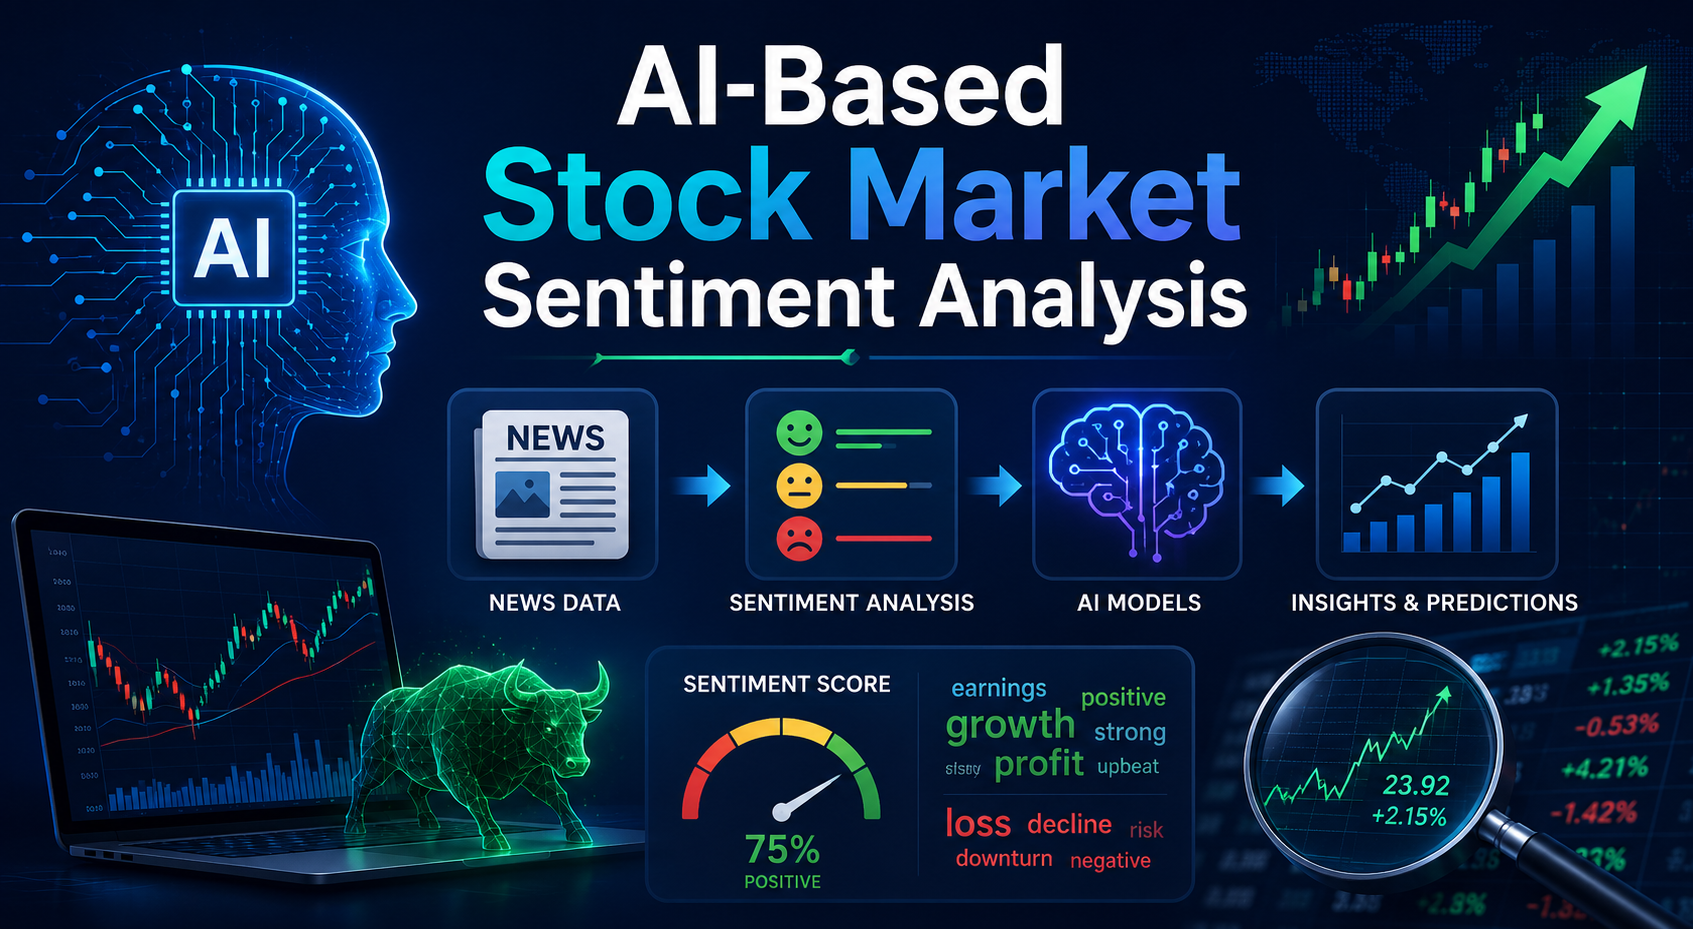

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## Whole Structure

```text
News Data
    ↓
Exploratory Data Analysis
    ↓
Text Embeddings
    ├── Word2Vec
    └── Sentence Transformer
            ↓
Classification Models
    ├── Random Forest
    └── Neural Network
            ↓
Model Evaluation
    ├── Accuracy
    ├── Precision
    ├── Recall
    ├── F1-Score
    └── Confusion Matrix
            ↓
Final Model Selection
```

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [2]:
!pip install  gensim==4.3.3

In [3]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [4]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/Dataset/GenAIDataset/stock_news.csv")

Mounted at /content/drive


In [5]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

* This helps us understand the structure and content of the dataset.  




In [6]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

*   This helps us verify the latest records in the dataset.


In [7]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

*   This shows the number of rows and columns.



In [8]:
data.shape

(349, 8)



*   Detailed View



In [9]:
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

Number of rows: 349
Number of columns: 8


###**Checking for missing values**



*   Missing values can affect data analysis and model performance.



In [10]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


### **Checking for duplicate values**

In [11]:
# checking for duplicate values
data.duplicated().sum()

0

### **Checking the number of unique values**

* This helps us understand the variety of values present in each column.

In [12]:
data.nunique()

,0
Date,71
News,349
Open,70
High,70
Low,71
Close,71
Volume,71
Label,3


##**Exploratory Data Analysis**

---
* Exploratory Data Analysis (EDA) is performed to understand the structure,
distribution, patterns, and relationships present in the dataset.

* The analysis focuses on three major aspects:

  1.   Understanding the dataset and its data types
  2.   Exploring the distribution of stock prices, trading volume, and news content
  3.  Studying the relationship between news sentiment and stock market variables
  









## **Data Understanding**

In [13]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


In [14]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])


In [15]:
# To ensure the data type of Date
data.dtypes

,0
Date,datetime64[ns]
News,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64
Label,int64


In [16]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

In [17]:
sentiment_percentage = (
    data['Label']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

sentiment_percentage

,proportion
Label,
0,48.71
-1,28.37
1,22.92


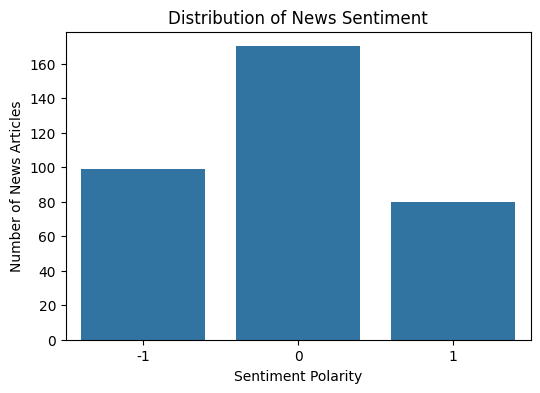

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=data,
    x='Label',
    order=[-1, 0, 1]
)

plt.title('Distribution of News Sentiment')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of News Articles')

plt.show()

### Key Insight

* The sentiment distribution helps identify whether the dataset is balanced
across positive, neutral, and negative news categories.

* If one sentiment category dominates the dataset, class imbalance should be
considered while training and evaluating the classification models.

### **Distribution of Sentiment polarity and all Numeric Variables**

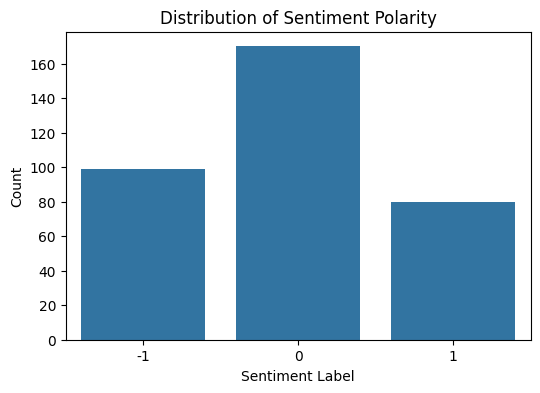

In [19]:
# Distribution of sentiment polarity
plt.figure(figsize=(6, 4))

sns.countplot(data=data, x='Label')

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')

plt.show()

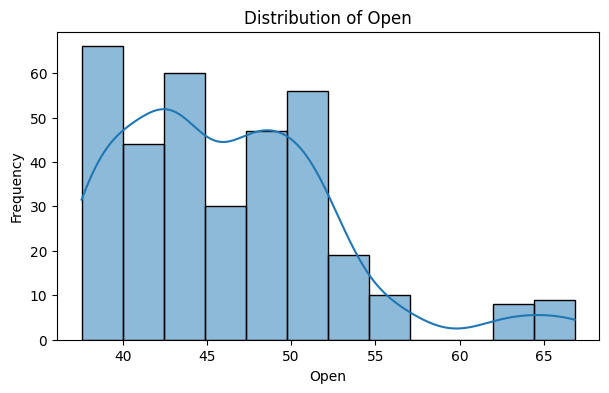

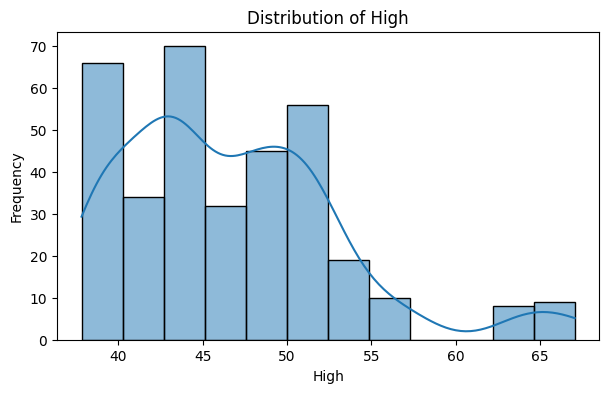

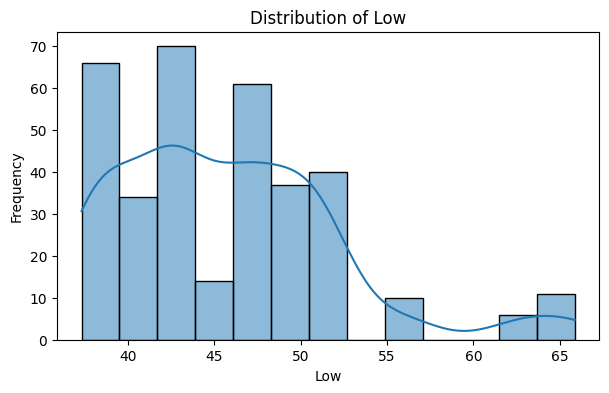

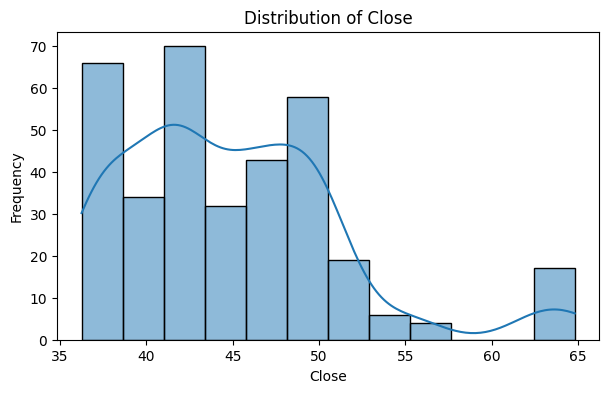

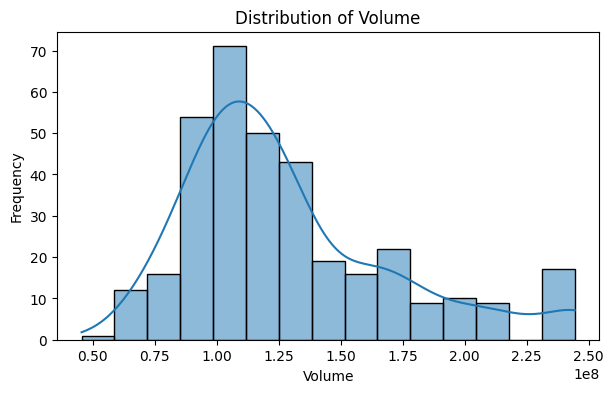

In [20]:
# Plot Distribution of all Numeric variables
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

for column in numeric_columns:

    plt.figure(figsize=(7, 4))

    sns.histplot(data[column], kde=True)

    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.show()

### **Distribution of the length of news content**

In [21]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))

# Summary statistics of news length
data['News_Length'].describe()

,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


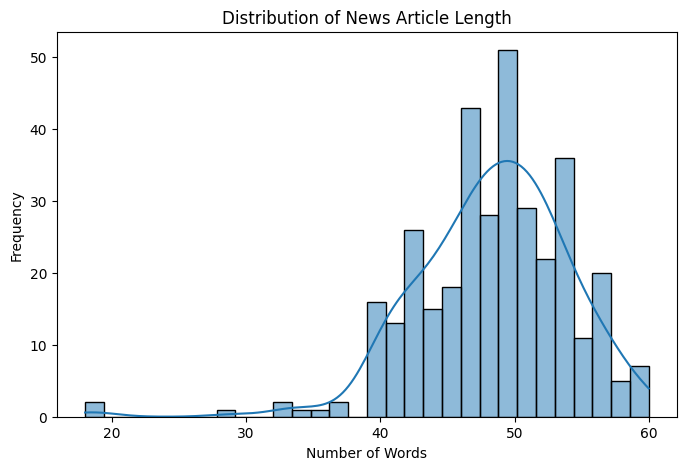

In [22]:
# Plot distribution
plt.figure(figsize=(8, 5))

sns.histplot(data['News_Length'], bins=30, kde=True)

plt.title('Distribution of News Article Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()

### **Monthwise Analysis**

In [23]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


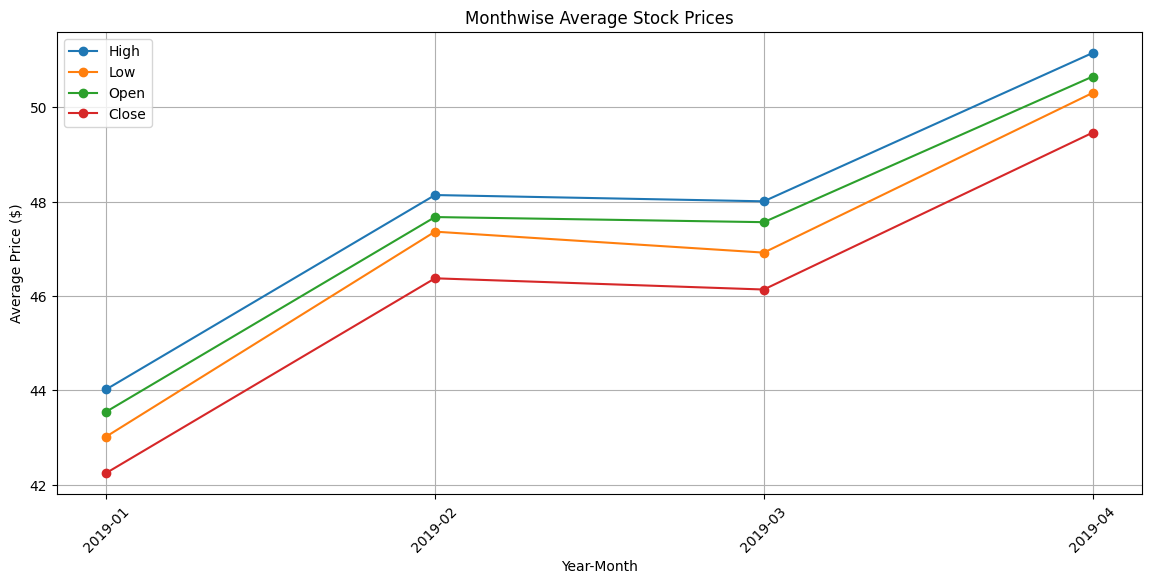

In [24]:
# plot the monthwise averages of all price variables for better visualization
plt.figure(figsize=(14, 6))

for column in ['High', 'Low', 'Open', 'Close']:

    plt.plot(
        monthwise_avg['YearMonth'],
        monthwise_avg[column],
        marker='o',
        label=column
    )

plt.title('Monthwise Average Stock Prices')
plt.xlabel('Year-Month')
plt.ylabel('Average Price ($)')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()



* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

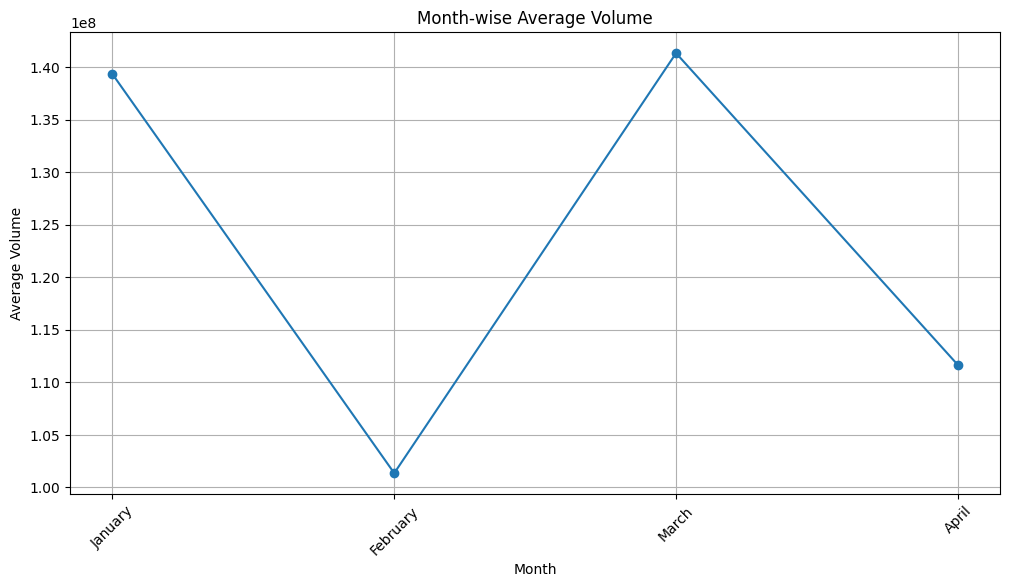

In [25]:
#plot the trend of monthwise averages in Volume
# Calculate month-wise average Volume
monthly_volume = data.groupby(data['Date'].dt.month_name())['Volume'].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_volume = monthly_volume.reindex(month_order)

# Plot the trend
plt.figure(figsize=(12,6))
plt.plot(monthly_volume.index, monthly_volume.values, marker='o')
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [26]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

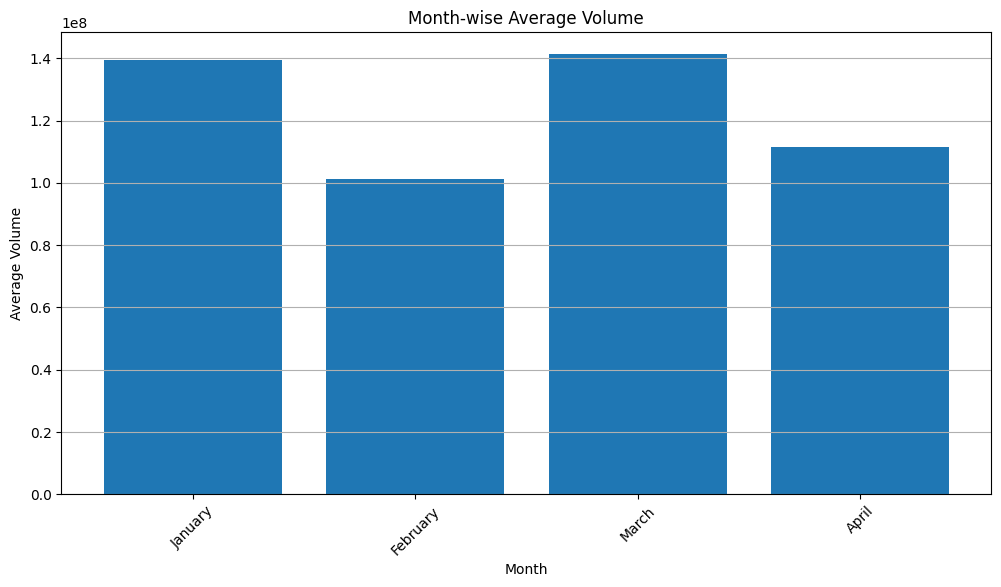

In [27]:
# Bar plot of the monthwise averages in Volume
# Calculate month-wise average Volume
monthly_volume = data.groupby(data['Date'].dt.month_name())['Volume'].mean()

# Arrange months in calendar order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_volume = monthly_volume.reindex(month_order)

# Bar plot
plt.figure(figsize=(12,6))
plt.bar(monthly_volume.index, monthly_volume.values)
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

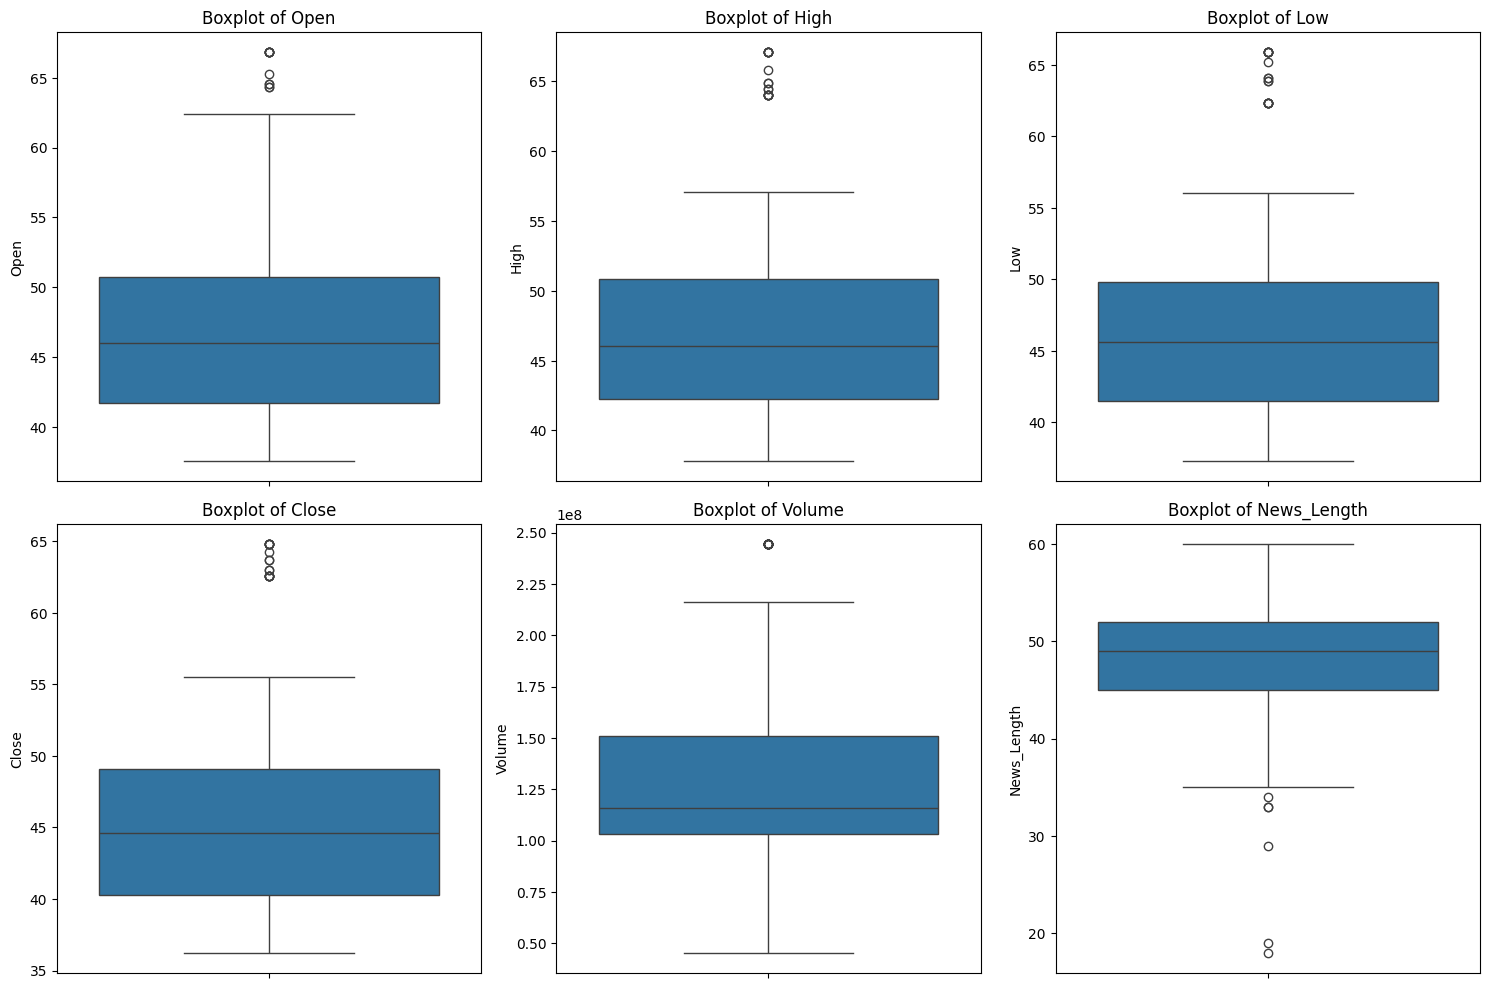

In [28]:
# Boxplot to identify outliers
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

### Key Insight

* The correlation matrix helps us understand the strength and direction of linear relationships between stock prices, trading volume, and sentiment polarity.

* A positive correlation indicates that two variables tend to increase together, while a negative correlation indicates that one variable tends to decrease as the other increases.

* However, correlation does not imply causation. Therefore, the results should be interpreted as relationships or associations rather than proof that one variable directly causes another.

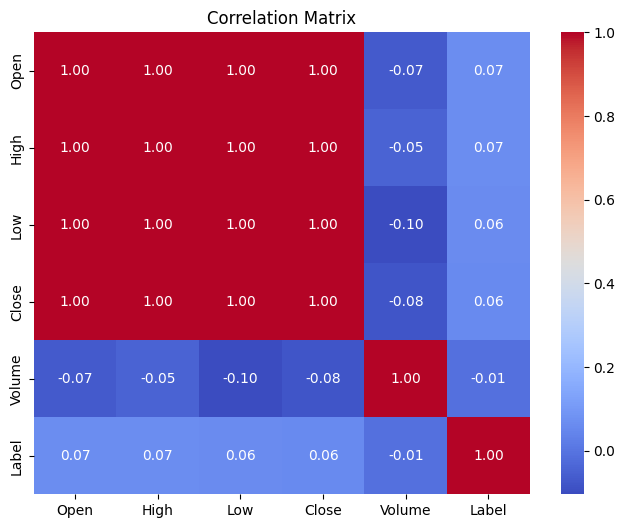

In [29]:
# Correlation matrix to check if variables move together or have correlations

plt.figure(figsize=(8, 6))

correlation_matrix = data[
    ['Open', 'High', 'Low', 'Close', 'Volume', 'Label']
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

### **Sentiment Polarity vs Price**

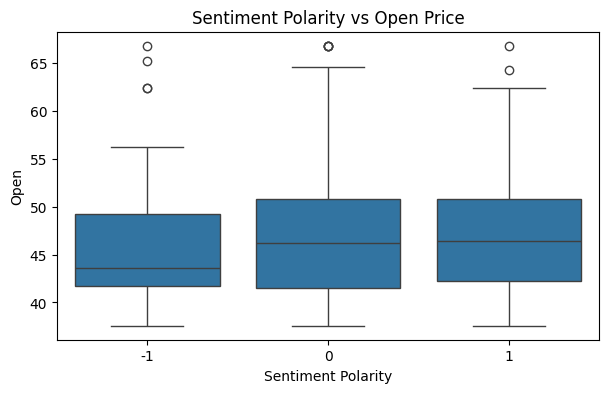

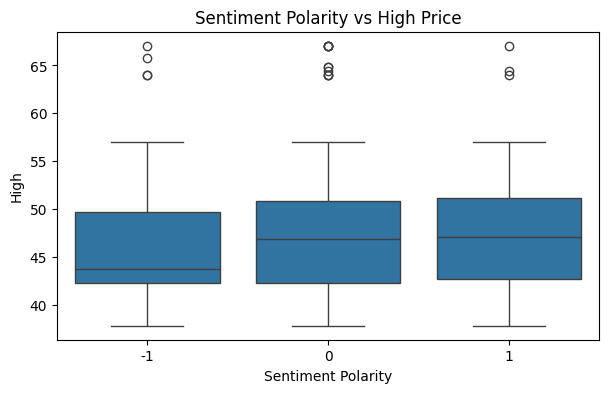

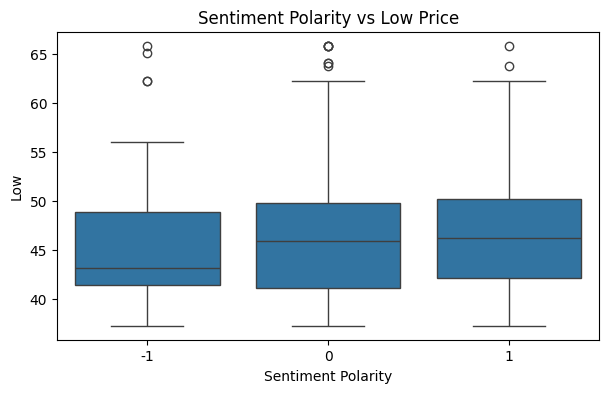

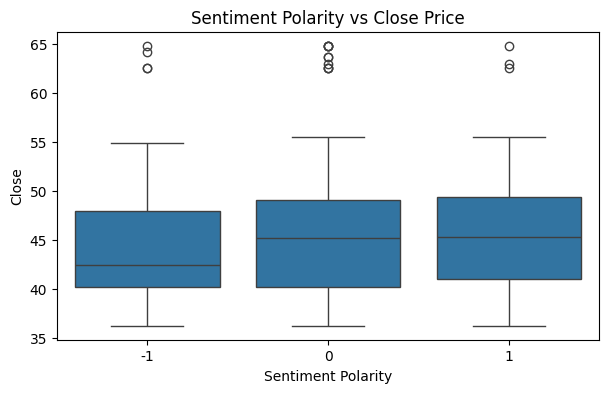

In [30]:
#Sentiment Polarity with all numeric variables

price_columns = ['Open', 'High', 'Low', 'Close']

for column in price_columns:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=data,
        x='Label',
        y=column
    )

    plt.title(f'Sentiment Polarity vs {column} Price')
    plt.xlabel('Sentiment Polarity')
    plt.ylabel(column)

    plt.show()

In [31]:
sentiment_price_summary = (
    data.groupby('Label')[
        ['Open', 'High', 'Low', 'Close', 'Volume']
    ]
    .mean()
    .round(2)
)

sentiment_price_summary

,Open,High,Low,Close,Volume
Label,,,,,
-1,45.35,45.82,44.91,44.09,1.268821e+08
0,46.64,47.10,46.14,45.34,1.321492e+08
1,46.46,46.94,45.94,45.09,1.247030e+08


### **Time Series Analysis (Date vs Price)**

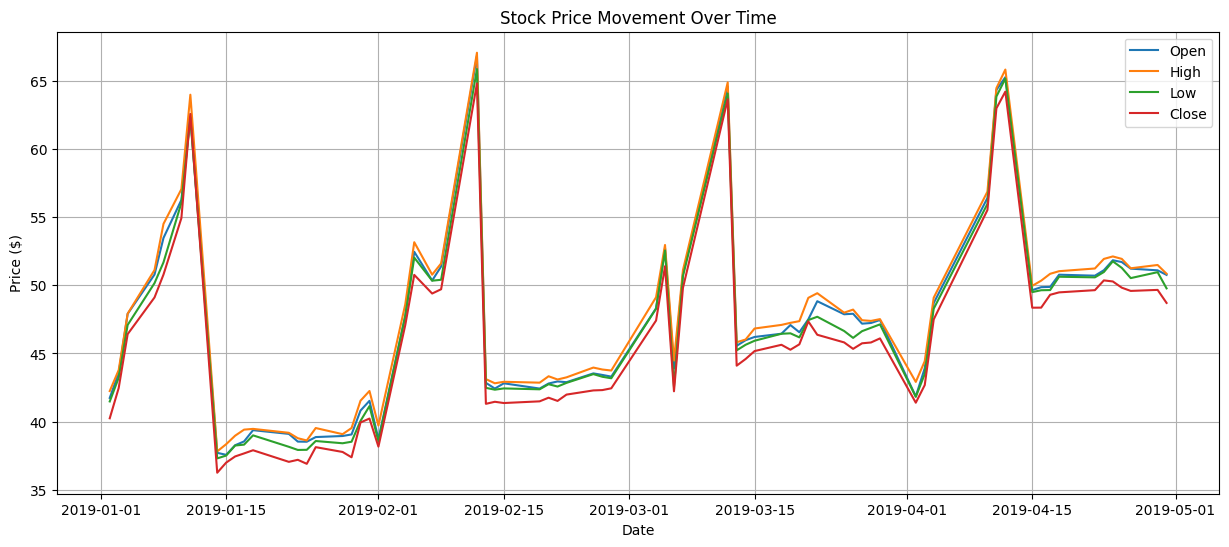

In [32]:
#Time Series Analysis (Date vs Price columns)

plt.figure(figsize=(15, 6))

for column in ['Open', 'High', 'Low', 'Close']:

    plt.plot(
        data['Date'],
        data[column],
        label=column
    )

plt.title('Stock Price Movement Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')

plt.legend()
plt.grid(True)

plt.show()

###Key Insight

* The time-series plot shows how the stock's opening, highest, lowest, and closing prices changed over the observed period. This helps identify general trends and periods of noticeable price movement.

### **Distribution of News Length Across Sentiment Categories**

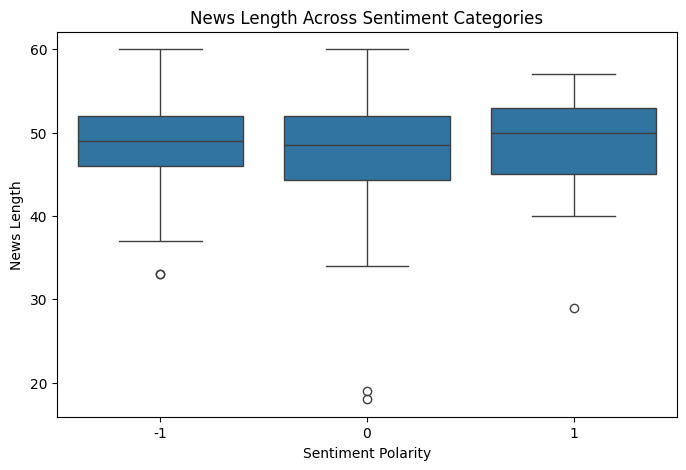

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x='Label',
    y='News_Length'
)

plt.title('News Length Across Sentiment Categories')
plt.xlabel('Sentiment Polarity')
plt.ylabel('News Length')

plt.show()

### 🔍 Key Insights from Exploratory Data Analysis

The exploratory analysis provides the following observations:

- The dataset contains historical news articles along with daily stock market information.
- The sentiment distribution shows the proportion of negative, neutral, and positive news articles.
- The distributions of the stock price variables and trading volume help us understand their general patterns and spread.
- The stock prices show noticeable movement over the observed time period.



## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [34]:
# Storing target variable
y = data['Label'].values


## **Word Embeddings**


#### **Word2Vec**

In [35]:
# Creating a list of all words in our data

sentences = data['News'].apply(lambda x: str(x).lower().split()).tolist()

In [36]:
# Train the Word2Vec model
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [37]:
# Size of each word vector
vec_size = word2vec_model.vector_size

In [38]:
# Retrieving word vectors for all the words present in the model's vocabulary
words = word2vec_model.wv.index_to_key
word_vectors = word2vec_model.wv.vectors

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = dict(zip(words, word_vectors))

In [39]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [40]:
# creating a dataframe of the vectorized documents
X_word2vec = np.array(data['News'].apply(average_vectorizer_Word2Vec).tolist())

# Checking the shape of the vectorized documents
print("Word2Vec Embedding Shape:", X_word2vec.shape)

Word2Vec Embedding Shape: (349, 100)


## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [41]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Sentence Transformer

* Sentence Transformers convert complete sentences or news articles into
numerical vectors.

* Unlike Word2Vec, which represents individual words, Sentence Transformers
generate embeddings that capture the overall meaning and context of the
complete news article.

##### Encoding the dataset

In [42]:
embedding_matrix = model.encode(
    data['News'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

* Here, each news article is passed through the Sentence Transformer model and converted into a numerical vector called an embedding.

In [43]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

#### **Generating Embeddings with Sentence Transformers using the all-MiniLM-L6-v2 text embedding**

In [44]:
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Encoding the dataset

In [45]:
embedding_matrix_minilm = model_minilm.encode(
    data['News'].tolist(),
    show_progress_bar=True
)


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [46]:
# printing the shape of the MiniLM embedding matrix
embedding_matrix_minilm.shape


(349, 384)

## **Sentiment Analysis**

* The generated text embeddings are used as input features for the sentiment
classification models.


### **Model Evaluation Criterion**

  The models are evaluated using multiple performance metrics:

- **Accuracy**: Measures the overall percentage of correctly classified news articles.
- **Precision**: Measures how many of the articles predicted as a particular sentiment actually belong to that sentiment.
- **Recall**: Measures how many of the actual articles belonging to a sentiment class were correctly identified.
- **F1-Score**: Provides a balance between Precision and Recall.
- **Confusion Matrix**: Shows the number of correct and incorrect predictions for each sentiment category.

Using multiple evaluation metrics provides a more complete understanding of
model performance than relying on accuracy alone.

##### **Utility Functions**

In [47]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [48]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [54]:
X = X_word2vec

In [55]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [56]:
# Building the model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
# Fitting on train data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [57]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)
# Predicting on test data
y_pred_test = rf_model.predict(X_test)

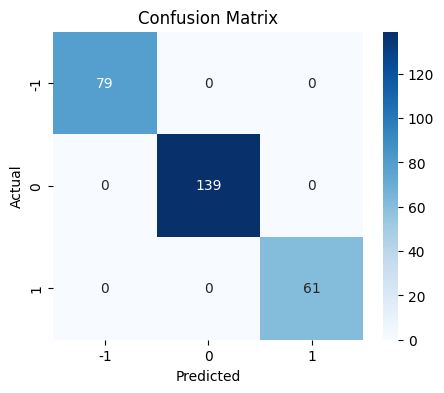

In [58]:
plot_confusion_matrix(y_train, y_pred_train)

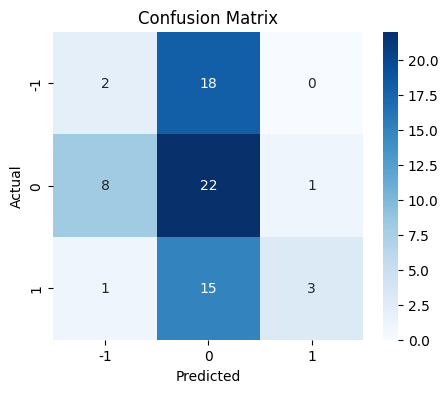

In [59]:
plot_confusion_matrix(y_test, y_pred_test)

In [60]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.385714 0.385714   0.432662 0.334252


###**Sentence Transformer-Random Forest Model**

In [61]:
# Storing independent variable
X = embedding_matrix


In [62]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
# Building the model
from sklearn.ensemble import RandomForestClassifier


# Fitting on train data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [64]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)


# Predicting on test data
y_pred_test = rf_model.predict(X_test)

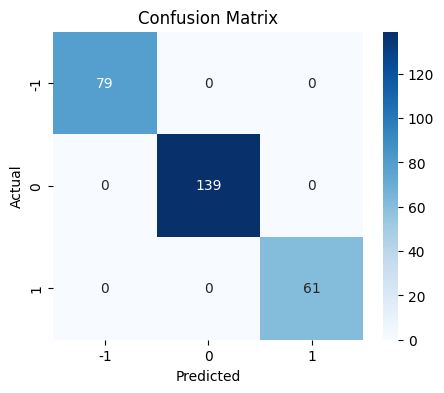

In [65]:
plot_confusion_matrix(y_train, y_pred_train)

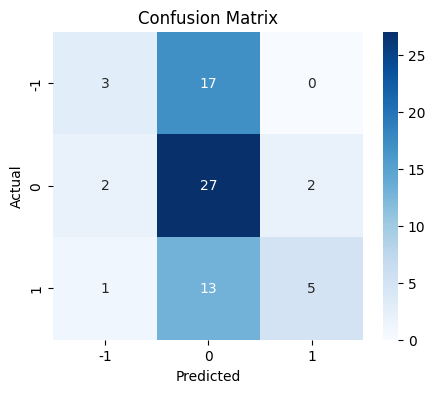

In [66]:
plot_confusion_matrix(y_test, y_pred_test)

In [67]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


###**Sentence Transformer (all-MiniLM-L6-v2) - Random Forest Model**

In [68]:
# Storing independent variable
X = embedding_matrix_minilm


In [69]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [70]:
# Building the model
from sklearn.ensemble import RandomForestClassifier

# Fitting on train data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [71]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)

# Predicting on test data
y_pred_test = rf_model.predict(X_test)


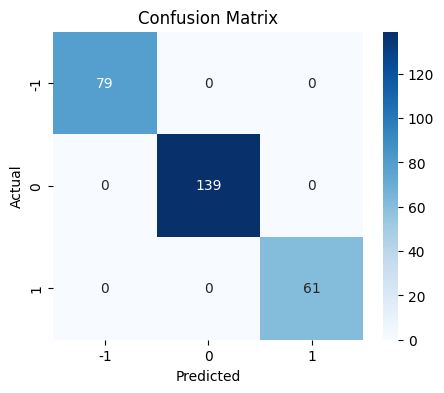

In [72]:
plot_confusion_matrix(y_train, y_pred_train)


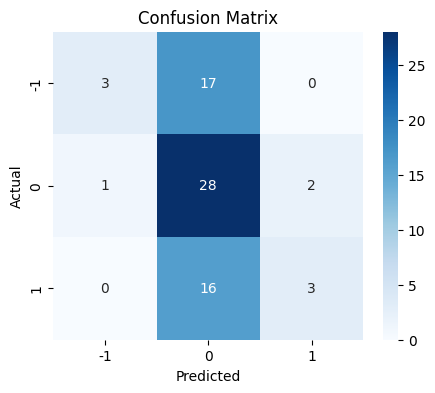

In [73]:
plot_confusion_matrix(y_test, y_pred_test)


In [74]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [75]:
# Storing independent variable
X = embedding_matrix

In [76]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [77]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [78]:

model =Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4910 - loss: 1.0688 - val_accuracy: 0.4429 - val_loss: 1.0596
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0025 - val_accuracy: 0.4429 - val_loss: 1.0464
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5018 - loss: 0.9495 - val_accuracy: 0.4429 - val_loss: 1.0036
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5269 - loss: 0.8940 - val_accuracy: 0.4714 - val_loss: 0.9655
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5986 - loss: 0.8267 - val_accuracy: 0.4857 - val_loss: 0.9374
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6416 - loss: 0.7618 - val_accuracy: 0.5429 - val_loss: 0.9149
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7204 - loss: 0.6927 - val_accuracy: 0.5857 - val_loss: 0.9093
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7097 - loss: 0.6324 - val_accuracy: 0.5714 - val_loss: 0.9205


In [80]:
# Predict class probabilities on training data
y_train_prob = model.predict(X_train)


# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_prob, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [81]:
# Predict class probabilities on test data
y_test_prob = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_prob, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


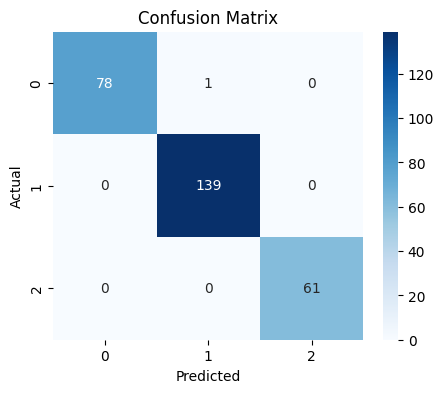

In [82]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

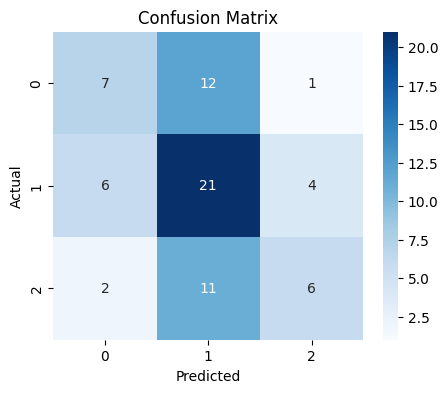

In [83]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [84]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.996416 0.996416   0.996441 0.996411
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.492749 0.470857


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [85]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [87]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4731 - loss: 1.0608 - val_accuracy: 0.4429 - val_loss: 1.0625
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 1.0253 - val_accuracy: 0.4429 - val_loss: 1.0594
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4982 - loss: 0.9711 - val_accuracy: 0.4429 - val_loss: 1.0192
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5341 - loss: 0.9161 - val_accuracy: 0.4714 - val_loss: 0.9838
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5591 - loss: 0.8482 - val_accuracy: 0.5286 - val_loss: 0.9524
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6416 - loss: 0.7854 - val_accuracy: 0.5571 - val_loss: 0.9263
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6595 - loss: 0.7120 - val_accuracy: 0.5429 - val_loss: 0.9201
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7312 - loss: 0.6791 - val_accuracy: 0.5429 - val_loss: 0.9308


In [89]:
# Predict class probabilities on training data
train_probabilities = model.predict(X_train)


# Convert probabilities to class labels
y_train_preds = np.argmax(train_probabilities,axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [90]:
# Predict class probabilities on test data
test_probabilities = model.predict(X_test)


# Convert probabilities to class labels
y_test_preds = np.argmax(test_probabilities,axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


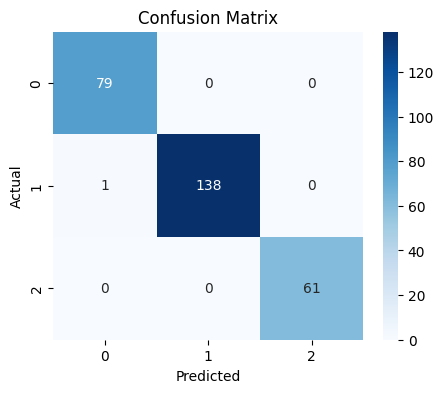

In [91]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

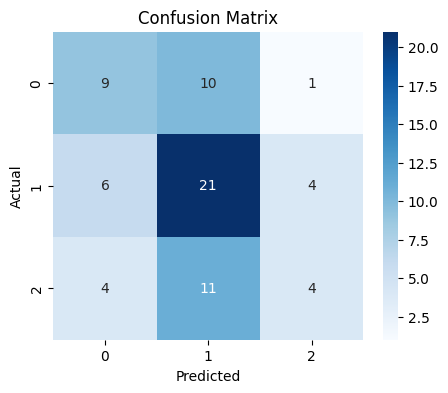

In [92]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [93]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.996416 0.996416   0.996461 0.996421
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.477402 0.464214


Key Insight

* The Sentence Transformer–Neural Network model achieved an accuracy of approximately 49.82% on the training set and 44.29% on the test set. The relatively low F1-score and precision indicate that the model has difficulty distinguishing between the different sentiment classes.

* The small difference between the training and test performance suggests that the model is not heavily overfitting the training data. However, the overall performance indicates that the current neural network architecture may not be learning sufficiently useful patterns from the embeddings.

### **Generating Embeddings with Sentence Transformers using the all-MiniLM-L6-v2 embedding -Neural Network model**

In [94]:
# Storing independent variable
X = embedding_matrix_minilm


In [95]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [96]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])


In [97]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')   # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4480 - loss: 1.0747 - val_accuracy: 0.4429 - val_loss: 1.0701
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4982 - loss: 1.0167 - val_accuracy: 0.4429 - val_loss: 1.0559
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4982 - loss: 0.9682 - val_accuracy: 0.4429 - val_loss: 1.0413
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5376 - loss: 0.9155 - val_accuracy: 0.4429 - val_loss: 1.0237
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6165 - loss: 0.8569 - val_accuracy: 0.5571 - val_loss: 1.0000
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6380 - loss: 0.7914 - val_accuracy: 0.5143 - val_loss: 0.9813
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6810 - loss: 0.7254 - val_accuracy: 0.5714 - val_loss: 0.9809
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7563 - loss: 0.6536 - val_accuracy: 0.5714 - val_loss: 0.9535


In [99]:
# Predict class probabilities on training data
train_probabilities = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(train_probabilities, axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [100]:
# Predict class probabilities on test data
test_probabilities = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(test_probabilities, axis=1)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


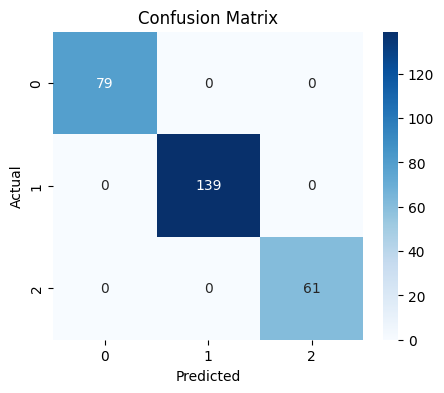

In [101]:
plot_confusion_matrix(y_train_mapped, y_train_preds)


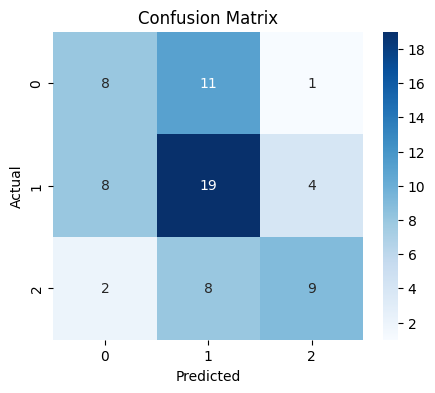

In [102]:
plot_confusion_matrix(y_test_mapped, y_test_preds)


In [103]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.514286 0.514286   0.522902 0.512245


### **Model Performance Summary and Final Model Selection**

In [104]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df


Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.996416,1.0,0.996416,1.0,1.0
Recall,1.0,0.996416,1.0,0.996416,1.0,1.0
Precision,1.0,0.996441,1.0,0.996461,1.0,1.0
F1,1.0,0.996411,1.0,0.996421,1.0,1.0


In [105]:
# Test performance comparison
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,
        test_Word2Vec_NN.T,
        test_transformer_BAAI_RF.T,
        test_transformer_BAAI_NN.T,
        test_transformer_MiniLM_RF.T,
        test_transformer_MiniLM_NN.T
    ],
    axis=1
)

models_test_comp_df.columns = [
    "Word2Vec - Random Forest",
    "Word2Vec - Neural Network",
    "BAAI Sentence Transformer - Random Forest",
    "BAAI Sentence Transformer - Neural Network",
    "MiniLM Sentence Transformer - Random Forest",
    "MiniLM Sentence Transformer - Neural Network"
]

print("Test Performance Comparison:")
models_test_comp_df


Test Performance Comparison:


,Word2Vec - Random Forest,Word2Vec - Neural Network,BAAI Sentence Transformer - Random Forest,BAAI Sentence Transformer - Neural Network,MiniLM Sentence Transformer - Random Forest,MiniLM Sentence Transformer - Neural Network
Accuracy,0.385714,0.485714,0.500000,0.485714,0.485714,0.514286
Recall,0.385714,0.485714,0.500000,0.485714,0.485714,0.514286
Precision,0.432662,0.492749,0.546509,0.477402,0.580422,0.522902
F1,0.334252,0.470857,0.442083,0.464214,0.408851,0.512245


### **Final Model Selection**

In [106]:
# Selecting the model with the highest test F1-score across all 6 models
best_model_name = models_test_comp_df.loc['F1'].astype(float).idxmax()
print(f"Selected Model ({best_model_name}) Test Performance:")
display(models_test_comp_df[[best_model_name]])


Selected Model (MiniLM Sentence Transformer - Neural Network) Test Performance:


,MiniLM Sentence Transformer - Neural Network
Accuracy,0.514286
Recall,0.514286
Precision,0.522902
F1,0.512245


### **Model Performance Summary and Final Model Selection**

The performance of all trained models is compared using Accuracy, Recall,
Precision, and F1-Score.

Both training and test performance are analyzed. However, the test-set
performance is given greater importance during final model selection because
it provides a better indication of how the model may perform on unseen data.

The F1-Score is used as the primary metric for comparison, while Accuracy,
Precision, Recall, and the Confusion Matrix are also considered.

## **Conclusions and Recommendations**

#### **Conclusions**

**Word2Vec**
  * Word2Vec provided a simple method for converting news articles into numerical
representations. Its performance was evaluated using both Random Forest and
Neural Network models.

**Sentence Transformer embeddings**
  * The Sentence Transformer embeddings provided a contextual representation of
the news articles. Their performance was compared with the Word2Vec
embeddings to understand the effect of different text representation
techniques.

**Neural Networks**
  * The Neural Network models were trained using the generated text embeddings.
Their performance was compared with the Random Forest models using the same
evaluation metrics.

**Random Forest**
  * The Random Forest models provided a tree-based approach for sentiment
classification. Their performance was compared with Neural Networks to
identify the most suitable model for the given dataset.


#### **Recommendations**

- The model with the best test-set performance should be selected as the final
  sentiment classification model.

- The selected model can be further improved by tuning hyperparameters such as
  the number of estimators in Random Forest or the number of layers and
  neurons in the Neural Network.

- Additional text preprocessing techniques can be explored to improve the
  quality of the input text.

- More training data may help the models learn better sentiment patterns.

- Future work can investigate the relationship between news sentiment and
  stock price movement using time-series analysis.